En el presente documento de busca saber qué día de Semana Santa es en el que se ha reportado mayor préstamo de bicicletas en la Ciudad de México.

In [261]:
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [262]:
df = pd.read_csv("datos_limpios.csv", sep=',')
df=pd.DataFrame(df)

df

C:\Users\aripi\AppData\Local\Temp\ipykernel_50244\3481539578.py:1: DtypeWarning: Columns (0,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("datos_limpios.csv", sep=',')


,Ciclo_Estacion_Retiro,Fecha_Retiro,Ciclo_Estacion_Arribo
0,52,2015-03-29,35
1,52,2015-03-29,35
2,208,2015-03-29,206
3,59,2015-03-29,141
4,59,2015-03-29,141
...,...,...,...
1826697,611,2025-04-20,562
1826698,180,2025-04-20,393
1826699,493,2025-04-20,261
1826700,354,2025-04-20,290


In [263]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826702 entries, 0 to 1826701
Data columns (total 3 columns):
 #   Column                 Dtype 
---  ------                 ----- 
 0   Ciclo_Estacion_Retiro  object
 1   Fecha_Retiro           object
 2   Ciclo_Estacion_Arribo  object
dtypes: object(3)
memory usage: 41.8+ MB


Análisis de NaN:

In [264]:
total_filas = len(df)

# Resumen de faltantes por columna
faltantes_resumen = pd.DataFrame({
    "faltantes": df.isna().sum(),
    "porcentaje_faltantes": (df.isna().sum() / total_filas) * 100
})

# Opcional: ordenar de mayor a menor porcentaje de faltantes
faltantes_resumen = faltantes_resumen.sort_values(by="porcentaje_faltantes", ascending=False)

# Opcional: redondear porcentaje a 2 decimales
faltantes_resumen["porcentaje_faltantes"] = faltantes_resumen["porcentaje_faltantes"].round(2)

faltantes_resumen

,faltantes,porcentaje_faltantes
Ciclo_Estacion_Retiro,0,0.0
Fecha_Retiro,0,0.0
Ciclo_Estacion_Arribo,0,0.0


Se observa que el presente dataframe no tiene datos faltantes (NaN).

In [265]:
df.describe(include="all")

,Ciclo_Estacion_Retiro,Fecha_Retiro,Ciclo_Estacion_Arribo
count,1826702,1826702,1826702
unique,1901,88,1903
top,27,2024-03-26,271-272
freq,9246,66491,13634


Se procede a agrupar las fechas por año:

In [266]:
df["Fecha_Retiro"] = pd.to_datetime(
        df["Fecha_Retiro"],
        errors="coerce"   # convierte errores en NaT
    )
df

,Ciclo_Estacion_Retiro,Fecha_Retiro,Ciclo_Estacion_Arribo
0,52,2015-03-29,35
1,52,2015-03-29,35
2,208,2015-03-29,206
3,59,2015-03-29,141
4,59,2015-03-29,141
...,...,...,...
1826697,611,2025-04-20,562
1826698,180,2025-04-20,393
1826699,493,2025-04-20,261
1826700,354,2025-04-20,290


In [267]:
# agrupar por dia
df1= (df.groupby("Fecha_Retiro").size().reset_index(name="num_Retiros"))
df1["año"] = df1["Fecha_Retiro"].dt.year
df1["mes"] = df1["Fecha_Retiro"].dt.month
df1["dia"] = df1["Fecha_Retiro"].dt.day
df1["dia_semana"] = df1["Fecha_Retiro"].dt.day_name()
df1["dia_semana_num"] = df1["Fecha_Retiro"].dt.weekday
df1

,Fecha_Retiro,num_Retiros,año,mes,dia,dia_semana,dia_semana_num
0,2015-03-29,11915,2015,3,29,Sunday,6
1,2015-03-30,29726,2015,3,30,Monday,0
2,2015-03-31,30852,2015,3,31,Tuesday,1
3,2015-04-01,23860,2015,4,1,Wednesday,2
4,2015-04-02,11522,2015,4,2,Thursday,3
...,...,...,...,...,...,...,...
83,2025-04-16,57245,2025,4,16,Wednesday,2
84,2025-04-17,40971,2025,4,17,Thursday,3
85,2025-04-18,35690,2025,4,18,Friday,4
86,2025-04-19,35250,2025,4,19,Saturday,5


La tabla anterior muestra el número de retiros por día desde el 2015 al 2025 durante la Semana Santa.

El siguiente código es para la visualización de los datos

In [268]:
df1=df1.drop(columns=["Fecha_Retiro", "dia_semana"])
df1

,num_Retiros,año,mes,dia,dia_semana_num
0,11915,2015,3,29,6
1,29726,2015,3,30,0
2,30852,2015,3,31,1
3,23860,2015,4,1,2
4,11522,2015,4,2,3
...,...,...,...,...,...
83,57245,2025,4,16,2
84,40971,2025,4,17,3
85,35690,2025,4,18,4
86,35250,2025,4,19,5


In [269]:
x = df1.loc[:,].values
x = StandardScaler().fit_transform(x) 

In [270]:
feat_cols = ['feature'+str(i) for i in range(x.shape[1])]
FechasBicinorm = pd.DataFrame(x,columns=feat_cols)
FechasBicinorm.head()


,feature0,feature1,feature2,feature3,feature4
0,-0.568579,-1.581139,-1.390444,1.379937,1.239591
1,0.576620,-1.581139,-1.390444,1.488167,-1.593760
2,0.649018,-1.581139,-1.390444,1.596398,-1.121535
3,0.199452,-1.581139,0.719195,-1.650513,-0.649309
4,-0.593848,-1.581139,0.719195,-1.542283,-0.177084


In [271]:
pca_dates = PCA(n_components=2)
PCA_bikedates = pca_dates.fit_transform(x)


In [272]:
dfPCA = pd.DataFrame(data = PCA_bikedates, columns = ['pc1', 'pc2'])


In [273]:
def PCA2D(X, y=None):
    
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
   
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    
    plt.figure(figsize=(6,5))
    
    if y is not None:
        plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="viridis", alpha=0.7)
    else:
        plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7)
    
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Visualización PCA (2D)")
    plt.grid(True)
    
    plt.show()
    
    return X_pca

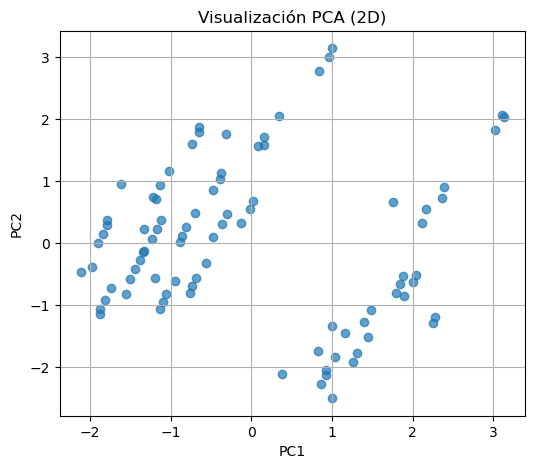

array([[ 1.0010065 , -2.49751238],
       [ 2.27342344, -1.18193528],
       [ 2.25061956, -1.28500209],
       [-1.34949652, -0.13978294],
       [-1.73656618, -0.72654836],
       [-1.81951287, -0.90947717],
       [-1.87429553, -1.05500772],
       [-1.87937852, -1.13454344],
       [ 0.37688541, -2.10870649],
       [ 1.16307357, -1.43877939],
       [ 1.48889778, -1.07891242],
       [ 1.40232574, -1.26665523],
       [ 1.03270643, -1.83024882],
       [ 0.92595151, -2.04479192],
       [ 0.92508906, -2.11872329],
       [ 0.86413792, -2.27244481],
       [-1.55578555, -0.81779866],
       [-0.30276689,  0.47201998],
       [-0.3645838 ,  0.31714885],
       [-0.47490994,  0.0978636 ],
       [-0.95150392, -0.60777873],
       [-1.05314548, -0.81553195],
       [-1.10067745, -0.95143451],
       [-1.13075907, -1.06416523],
       [ 0.83228098, -1.7327657 ],
       [ 2.03746676, -0.50646304],
       [ 2.00018856, -0.6287499 ],
       [ 1.89137748, -0.84602333],
       [ 1.44990063,

In [274]:
PCA2D(x)

Se observan 2 clústers bien diferenciados. Es posible que estos representen días de mayor o menor afluencia, quizá marcados por el fin de semana, lo que explicaría el clúster más pequeño como ser aquel de mayor cantidad de retiros. Se procederá a implementar un análisis más riguroso para confirmar y estudiar la naturaleza de los clústers.

El siguiente código busca encontrar en qué días de Semana Santa hay mayor cantidad de retiros de las bicicletas en Ciudad de México.

In [250]:
df = df.copy()
    
df["fecha"] = pd.to_datetime(df["Fecha_Retiro"])
    
    # retiros diarios
df_diario = (
    df.groupby("fecha")
    .size()
    .reset_index(name="num_Retiros")
    )
    
df_diario["dia_semana"] = df_diario["fecha"].dt.day_name()
df_diario["dia_semana_num"] = df_diario["fecha"].dt.weekday

In [251]:
df_diario

,fecha,num_Retiros,dia_semana,dia_semana_num
0,2015-03-29,11915,Sunday,6
1,2015-03-30,29726,Monday,0
2,2015-03-31,30852,Tuesday,1
3,2015-04-01,23860,Wednesday,2
4,2015-04-02,11522,Thursday,3
...,...,...,...,...
83,2025-04-16,57245,Wednesday,2
84,2025-04-17,40971,Thursday,3
85,2025-04-18,35690,Friday,4
86,2025-04-19,35250,Saturday,5


En la tabla anterior se muestran los días de la semana correspondientes a las fechas, así como el número de retiros hecho durante la semana.

In [257]:
SemanaSanta = (df_diario.groupby("dia_semana_num")["num_Retiros"].mean().reset_index())
dias = ["Lunes","Martes","Miércoles","Jueves","Viernes","Sábado","Domingo"]
SemanaSanta["dia"] = patron["dia_semana_num"].apply(lambda x: dias[x])
SemanaSanta=SemanaSanta.sort_values("dia_semana_num")
SemanaSanta

,dia_semana_num,num_Retiros,dia
0,0,28232.727273,Lunes
1,1,30325.818182,Martes
2,2,28324.545455,Miércoles
3,3,16698.363636,Jueves
4,4,14432.363636,Viernes
5,5,15265.545455,Sábado
6,6,16392.227273,Domingo


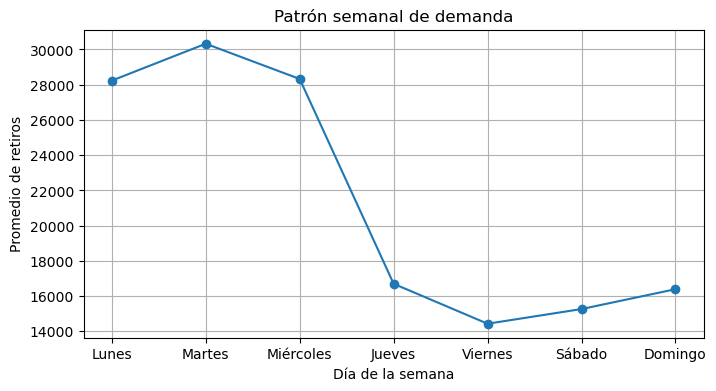

In [258]:
plt.figure(figsize=(8,4))
plt.plot(SemanaSanta["dia"], SemanaSanta["num_Retiros"], marker='o')
plt.title("Patrón semanal de demanda")
plt.xlabel("Día de la semana")
plt.ylabel("Promedio de retiros")
plt.grid(True)
plt.show()

En la gráfica anterior es posible observar que los Lunes, Martes y Miércoles de Semana Santa son en los que en promedio tienen mayor cantidad de retiros de bicicletas. Esto puede suceder porque estos días aún son días hábiles en México, mientras que el Jueves y Viernes, a pesar que la Ley Federal del Tabajo no los contempla como días de descanso obligatorio, muchas empresas otorgan esos días como días de descanso a sus trabajadores. Los centros educativos tienen esos días como días de descanso.
